# Module 06a: Pathway Enrichment Analysis (ORA)

## Biological Question
Does the SnC vs Non-SnC comparison enrich for senescence-associated pathways, validating that SenePy captures senescence biology in a cell-type-specific manner?

## Method
Over-representation analysis (ORA) using Enrichr API.

## Databases
- Core: Reactome, KEGG (comparable with SCPA in Module 06b)
- Extended: GO_BP, GO_MF, GO_CC, WikiPathway

## Gene Stratification
- All DEGs — Complete senescence signature
- In-SenePy — Canonical senescence genes (validation)
- Not-in-SenePy — Novel cell-type-specific genes (discovery)

## Cell Types
Microglia, Astrocyte, OPC

## Outputs
- Figure 2D: Dot plot
- Supplementary: Sankey diagrams, tier comparisons
- Tables: Enrichment results (CSV)

In [1]:
# ============================================================
# MODULE 06a: PATHWAY ENRICHMENT ANALYSIS (ORA)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
from pathlib import Path
from typing import Dict, List, Optional, Set

# ------------------------------------------------------------
# Dataset Selection
# ------------------------------------------------------------
DATASET = 'psychad_aging'  # Options: 'psychad_aging', 'psychad_ad', 'psychencode', 'mathys'

# ------------------------------------------------------------
# Dataset-Specific Configurations
# ------------------------------------------------------------
DATASET_CONFIG = {
    'psychad_aging': {
        'study_type': 'aging',
        'display_name': 'PsychAD Aging',
        'comparison': 'SnCvsNonSnC_all',
        'comparison_display': 'Senescent vs Non-Senescent',
    },
    'psychad_ad': {
        'study_type': 'disease',
        'display_name': 'PsychAD AD',
        'comparison': 'SnCvsNonSnC_all',
        'comparison_display': 'Senescent vs Non-Senescent',
    },
    'psychencode': {
        'study_type': 'aging',
        'display_name': 'PsychENCODE',
        'comparison': 'SnCvsNonSnC_all',
        'comparison_display': 'Senescent vs Non-Senescent',
    },
    'mathys': {
        'study_type': 'disease',
        'display_name': 'Mathys',
        'comparison': 'SnCvsNonSnC_all',
        'comparison_display': 'Senescent vs Non-Senescent',
    },
}

# Load configuration
config = DATASET_CONFIG[DATASET]
STUDY_TYPE = config['study_type']
DISPLAY_NAME = config['display_name']
COMPARISON = config['comparison']
COMPARISON_DISPLAY = config['comparison_display']

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
BASE_DIR = Path('/fs/scratch/PAS2598/senescence_analysis')

# Input from Module 05
INPUT_DIR = BASE_DIR / 'results' / '05_deg' / DATASET

# Output directories
OUTPUT_DIR = BASE_DIR / 'data' / '06_pathway_enrichment' / DATASET
RESULTS_DIR = BASE_DIR / 'results' / '06_pathway_enrichment' / DATASET
FIGURES_DIR = BASE_DIR / 'figures' / '06_pathway_enrichment' / DATASET

# Create directories
for d in [OUTPUT_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Analysis Parameters
# ------------------------------------------------------------
FDR_THRESHOLD = 0.05
LFC_THRESHOLD = 0.5   # From Module 05 DEG criteria
TOP_N_PATHWAYS = 15   # Per cell type for visualization
MIN_GENES = 5         # Minimum genes for enrichment

# Cell types
CELL_TYPES = ['Microglia'] #, 'Astrocyte'] #, 'OPC']

# Input file pattern: {input_dir}/{celltype_lower}/{dataset}_{celltype_lower}_{comparison}.csv
def get_deg_file(cell_type: str) -> Path:
    """Get DEG results file path for a cell type."""
    ct_lower = cell_type.lower()
    return INPUT_DIR / ct_lower / f"{DATASET}_{ct_lower}_{COMPARISON}.csv"

# ------------------------------------------------------------
# Databases
# ------------------------------------------------------------
DATABASES = {
    'core': ['Reactome_2022', 'KEGG_2021_Human'],
    'extended': ['GO_Biological_Process_2023', 
                 'GO_Molecular_Function_2023',
                 'GO_Cellular_Component_2023', 
                 'WikiPathway_2023_Human']
}

ALL_DATABASES = DATABASES['core'] + DATABASES['extended']

# ------------------------------------------------------------
# Color Palette (Modern Muted - Option C)
# ------------------------------------------------------------
COLORS = {
    # Direction
    'up': '#E76F51',        # Burnt sienna
    'down': '#2A9D8F',      # Teal
    
    # Cell types
    'Microglia': '#F4A261', # Sandy orange
    'Astrocyte': '#264653', # Dark slate
    'OPC': '#8AB17D',       # Sage green
    
    # Gene tiers
    'All_DEGs': '#6C757D',        # Neutral gray
    'In_SenePy': '#2A9D8F',       # Teal
    'Not_in_SenePy': '#E9C46A',   # Gold
    
    # Significance gradient
    'cmap': 'YlOrRd'
}

# ------------------------------------------------------------
# Publication Figure Settings
# ------------------------------------------------------------
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1
})

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print("=" * 60)
print("MODULE 06a: ORA PATHWAY ENRICHMENT")
print("=" * 60)
print(f"\nDataset: {DISPLAY_NAME} ({DATASET})")
print(f"Study type: {STUDY_TYPE}")
print(f"Comparison: {COMPARISON_DISPLAY}")
print(f"\nPaths:")
print(f"  Input:   {INPUT_DIR}/")
print(f"  Data:    {OUTPUT_DIR}/")
print(f"  Results: {RESULTS_DIR}/")
print(f"  Figures: {FIGURES_DIR}/")
print(f"\nExpected input files:")
for ct in CELL_TYPES:
    f = get_deg_file(ct)
    status = "✓" if f.exists() else "✗"
    print(f"  {status} {f.name}")
print(f"\nParameters:")
print(f"  FDR threshold: {FDR_THRESHOLD}")
print(f"  LFC threshold: {LFC_THRESHOLD}")
print(f"  Top pathways:  {TOP_N_PATHWAYS}")
print(f"  Min genes:     {MIN_GENES}")
print(f"\nCell types: {', '.join(CELL_TYPES)}")
print(f"\nDatabases:")
print(f"  Core:     {', '.join(DATABASES['core'])}")
print(f"  Extended: {', '.join(DATABASES['extended'])}")
print(f"\nSetup complete")

MODULE 06a: ORA PATHWAY ENRICHMENT

Dataset: PsychAD Aging (psychad_aging)
Study type: aging
Comparison: Senescent vs Non-Senescent

Paths:
  Input:   /fs/scratch/PAS2598/senescence_analysis/results/05_deg/psychad_aging/
  Data:    /fs/scratch/PAS2598/senescence_analysis/data/06_pathway_enrichment/psychad_aging/
  Results: /fs/scratch/PAS2598/senescence_analysis/results/06_pathway_enrichment/psychad_aging/
  Figures: /fs/scratch/PAS2598/senescence_analysis/figures/06_pathway_enrichment/psychad_aging/

Expected input files:
  ✓ psychad_aging_microglia_SnCvsNonSnC_all.csv

Parameters:
  FDR threshold: 0.05
  LFC threshold: 0.5
  Top pathways:  15
  Min genes:     5

Cell types: Microglia

Databases:
  Core:     Reactome_2022, KEGG_2021_Human
  Extended: GO_Biological_Process_2023, GO_Molecular_Function_2023, GO_Cellular_Component_2023, WikiPathway_2023_Human

Setup complete


In [2]:
# ============================================================
# Check if SenePy gene set exists, extract if needed
# NOTE: Extraction requires 'SenePy' conda environment
# ============================================================

print("=" * 60)
print("LOADING SENESPY GENE SET")
print("=" * 60)

# Central file location (shared across all datasets)
SENESPY_FILE = BASE_DIR / 'data' / 'reference' / 'senespy_genes.txt'

if SENESPY_FILE.exists():
    
    with open(SENESPY_FILE, 'r') as f:
        senespy_gene_set = set(line.strip() for line in f if line.strip())
    
    print(f"\n✓ Loaded SenePy gene set")
    print(f"  Path: {SENESPY_FILE}")
    print(f"  Genes: {len(senespy_gene_set)}")
    print(f"  Sample: {sorted(list(senespy_gene_set))[:10]}")

else:
    print(f"\n✗ File not found: {SENESPY_FILE}")
    print("\n" + "-" * 60)
    print("EXTRACTION REQUIRED")
    print("Run in 'SenePy' conda environment:")
    print("-" * 60)
    print('''
import senepy as sp
from pathlib import Path

hubs = sp.load_hubs(species='Human')
tissue_hubs = hubs.metadata[hubs.metadata.tissue == 'hippocampus']
hubs.merge_hubs(tissue_hubs, new_name='brain')

# Extract gene names only (first element of each tuple)
senespy_gene_set = set(gene for gene, score in hubs.hubs['brain'])
print(f"Extracted {len(senespy_gene_set)} genes")

SENESPY_FILE = Path('/fs/scratch/PAS2598/senescence_analysis/data/reference/senespy_genes.txt')
SENESPY_FILE.parent.mkdir(parents=True, exist_ok=True)

with open(SENESPY_FILE, 'w') as f:
    f.write('\\n'.join(sorted(senespy_gene_set)))

print(f"Saved to: {SENESPY_FILE}")
''')
    print("-" * 60)
    senespy_gene_set = set()
    print("\n⚠ Proceeding with empty gene set. Re-run after extraction.")

LOADING SENESPY GENE SET

✓ Loaded SenePy gene set
  Path: /fs/scratch/PAS2598/senescence_analysis/data/reference/senespy_genes.txt
  Genes: 3019
  Sample: ['AAMDC', 'AARS', 'AASDH', 'AATK', 'ABCA13', 'ABCA2', 'ABCA6', 'ABCA8', 'ABCB1', 'ABCC12']


In [3]:
# %% Load DEG Data
# ============================================================
# Load Module 05 DEG results
# ============================================================

print("=" * 60)
print("LOADING DEG DATA")
print("=" * 60)

# Column names from Module 05
COL_GENE = 'gene'
COL_SIGNIFICANT = 'significant'
COL_DIRECTION = 'direction'

# Load DEG results
dge_data = {}
all_tested_genes = set()

for ct in CELL_TYPES:
    deg_file = get_deg_file(ct)
    
    if not deg_file.exists():
        print(f"\n✗ {ct}: File not found - {deg_file}")
        continue
    
    df = pd.read_csv(deg_file)
    dge_data[ct] = df
    all_tested_genes.update(df[COL_GENE].tolist())
    
    n_up = len(df[(df[COL_SIGNIFICANT]) & (df[COL_DIRECTION] == 'Up')])
    n_down = len(df[(df[COL_SIGNIFICANT]) & (df[COL_DIRECTION] == 'Down')])
    
    print(f"\n✓ {ct}: {len(df):,} genes tested")
    print(f"    Significant: {n_up} up, {n_down} down")

print(f"\nBackground: {len(all_tested_genes):,} unique genes")
print(f"Loaded: {len(dge_data)}/{len(CELL_TYPES)} cell types")

LOADING DEG DATA

✓ Microglia: 33,557 genes tested
    Significant: 59 up, 36 down

Background: 33,557 unique genes
Loaded: 1/1 cell types


In [4]:
# ============================================================
# Extract significant DEGs and stratify by SenePy membership
# ============================================================

print("=" * 60)
print("EXTRACTING SIGNIFICANT DEGs")
print("=" * 60)

# All significant DEGs by direction
all_sig_degs = {}
all_sig_up = {}
all_sig_down = {}

for ct, df in dge_data.items():
    sig = df[df[COL_SIGNIFICANT] == True].copy()
    
    up = sig[sig[COL_DIRECTION] == 'Up'][COL_GENE].tolist()
    down = sig[sig[COL_DIRECTION] == 'Down'][COL_GENE].tolist()
    
    all_sig_degs[ct] = set(up + down)
    all_sig_up[ct] = set(up)
    all_sig_down[ct] = set(down)
    
    print(f"\n{ct}:")
    print(f"  Upregulated in SnC:   {len(up):>4} genes")
    print(f"  Downregulated in SnC: {len(down):>4} genes")
    print(f"  Total significant:    {len(all_sig_degs[ct]):>4} genes")

# ------------------------------------------------------------
# Stratify by SenePy membership
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("STRATIFYING BY SENESPY MEMBERSHIP")
print("=" * 60)

in_senespy_up = {}
in_senespy_down = {}
not_in_senespy_up = {}
not_in_senespy_down = {}

for ct in dge_data.keys():
    # In SenePy
    in_senespy_up[ct] = all_sig_up[ct] & senespy_gene_set
    in_senespy_down[ct] = all_sig_down[ct] & senespy_gene_set
    
    # Not in SenePy
    not_in_senespy_up[ct] = all_sig_up[ct] - senespy_gene_set
    not_in_senespy_down[ct] = all_sig_down[ct] - senespy_gene_set
    
    print(f"\n{ct}:")
    print(f"  In SenePy:     {len(in_senespy_up[ct]):>3} up, {len(in_senespy_down[ct]):>3} down")
    print(f"  Not in SenePy: {len(not_in_senespy_up[ct]):>3} up, {len(not_in_senespy_down[ct]):>3} down")

# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("DEG STRATIFICATION SUMMARY")
print("=" * 60)

summary_rows = []
for ct in dge_data.keys():
    summary_rows.append({
        'Cell_Type': ct,
        'All_Up': len(all_sig_up[ct]),
        'All_Down': len(all_sig_down[ct]),
        'All_Total': len(all_sig_degs[ct]),
        'InSenePy_Up': len(in_senespy_up[ct]),
        'InSenePy_Down': len(in_senespy_down[ct]),
        'NotSenePy_Up': len(not_in_senespy_up[ct]),
        'NotSenePy_Down': len(not_in_senespy_down[ct])
    })

summary_df = pd.DataFrame(summary_rows)
print("\n" + summary_df.to_string(index=False))

# Save summary
summary_file = RESULTS_DIR / f"{DATASET}_deg_stratification_summary.csv"
summary_df.to_csv(summary_file, index=False)
print(f"\n✓ Saved: {summary_file.name}")

EXTRACTING SIGNIFICANT DEGs

Microglia:
  Upregulated in SnC:     59 genes
  Downregulated in SnC:   36 genes
  Total significant:      95 genes

STRATIFYING BY SENESPY MEMBERSHIP

Microglia:
  In SenePy:       4 up,   8 down
  Not in SenePy:  55 up,  28 down

DEG STRATIFICATION SUMMARY

Cell_Type  All_Up  All_Down  All_Total  InSenePy_Up  InSenePy_Down  NotSenePy_Up  NotSenePy_Down
Microglia      59        36         95            4              8            55              28

✓ Saved: psychad_aging_deg_stratification_summary.csv


In [5]:
# ============================================================
# Enrichr REST API for over-representation analysis
# ============================================================

print("=" * 60)
print("DEFINING ENRICHR API FUNCTIONS")
print("=" * 60)

ENRICHR_URL = 'https://maayanlab.cloud/Enrichr'

def run_enrichr(gene_list: List[str], 
                gene_sets: str = 'GO_Biological_Process_2023',
                description: str = '') -> Optional[pd.DataFrame]:
    """
    Run enrichment analysis using Enrichr REST API.
    
    Parameters
    ----------
    gene_list : list
        List of gene symbols
    gene_sets : str
        Enrichr library name
    description : str
        Description for logging
    
    Returns
    -------
    pd.DataFrame or None
        Enrichment results
    """
    if len(gene_list) < MIN_GENES:
        print(f"    Skipping {description}: only {len(gene_list)} genes (min: {MIN_GENES})")
        return None
    
    try:
        # Step 1: Submit gene list
        genes_str = '\n'.join(gene_list)
        response = requests.post(
            f'{ENRICHR_URL}/addList',
            files={'list': (None, genes_str)}
        )
        
        if not response.ok:
            print(f"    Error submitting genes: {response.text}")
            return None
        
        user_list_id = response.json()['userListId']
        
        # Step 2: Get enrichment results
        response = requests.get(
            f'{ENRICHR_URL}/enrich',
            params={'userListId': user_list_id, 'backgroundType': gene_sets}
        )
        
        if not response.ok:
            print(f"    Error getting results: {response.text}")
            return None
        
        data = response.json()
        
        if gene_sets not in data:
            print(f"    No results for {gene_sets}")
            return None
        
        # Parse results
        results = []
        for item in data[gene_sets]:
            results.append({
                'Rank': item[0],
                'Term': item[1],
                'P-value': item[2],
                'Odds Ratio': item[3],
                'Combined Score': item[4],
                'Overlapping Genes': ';'.join(item[5]),
                'Adjusted P-value': item[6],
                'Gene_Count': len(item[5])
            })
        
        df = pd.DataFrame(results)
        df['database'] = gene_sets
        df['description'] = description
        
        return df
    
    except Exception as e:
        print(f"    Error in {description}: {e}")
        return None


def run_enrichment_all_databases(gene_list: List[str],
                                  description: str = '',
                                  databases: List[str] = None) -> Optional[pd.DataFrame]:
    """
    Run enrichment against multiple databases.
    
    Parameters
    ----------
    gene_list : list
        List of gene symbols
    description : str
        Description for logging
    databases : list, optional
        List of database names (default: ALL_DATABASES)
    
    Returns
    -------
    pd.DataFrame or None
        Combined enrichment results
    """
    if databases is None:
        databases = ALL_DATABASES
    
    all_results = []
    
    for db in databases:
        result = run_enrichr(gene_list, gene_sets=db, description=f"{description}_{db}")
        if result is not None and len(result) > 0:
            all_results.append(result)
    
    if all_results:
        return pd.concat(all_results, ignore_index=True)
    return None


print("✓ run_enrichr()")
print("✓ run_enrichment_all_databases()")
print(f"\nAvailable databases: {len(ALL_DATABASES)}")
for db in ALL_DATABASES:
    print(f"  • {db}")

DEFINING ENRICHR API FUNCTIONS
✓ run_enrichr()
✓ run_enrichment_all_databases()

Available databases: 6
  • Reactome_2022
  • KEGG_2021_Human
  • GO_Biological_Process_2023
  • GO_Molecular_Function_2023
  • GO_Cellular_Component_2023
  • WikiPathway_2023_Human


In [6]:
# ============================================================
# Run ORA for all three gene tiers
# ============================================================

print("=" * 60)
print("RUNNING ENRICHMENT ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# Tier 1: All DEGs
# ------------------------------------------------------------
print("\n" + "-" * 60)
print("TIER 1: ALL DEGs")
print("-" * 60)

all_degs_enrichment = {}

for ct in dge_data.keys():
    print(f"\n{ct}")
    print("-" * 40)
    
    all_degs_enrichment[ct] = {'up': None, 'down': None}
    
    # Upregulated
    up_genes = list(all_sig_up[ct])
    print(f"\n  Upregulated ({len(up_genes)} genes):")
    if len(up_genes) >= MIN_GENES:
        all_degs_enrichment[ct]['up'] = run_enrichment_all_databases(
            up_genes, description=f"{ct}_AllDEGs_UP"
        )
        if all_degs_enrichment[ct]['up'] is not None:
            n_sig = len(all_degs_enrichment[ct]['up'][
                all_degs_enrichment[ct]['up']['Adjusted P-value'] < FDR_THRESHOLD
            ])
            print(f"    ✓ {n_sig} significant pathways")
    else:
        print(f"    Skipped (< {MIN_GENES} genes)")
    
    # Downregulated
    down_genes = list(all_sig_down[ct])
    print(f"\n  Downregulated ({len(down_genes)} genes):")
    if len(down_genes) >= MIN_GENES:
        all_degs_enrichment[ct]['down'] = run_enrichment_all_databases(
            down_genes, description=f"{ct}_AllDEGs_DOWN"
        )
        if all_degs_enrichment[ct]['down'] is not None:
            n_sig = len(all_degs_enrichment[ct]['down'][
                all_degs_enrichment[ct]['down']['Adjusted P-value'] < FDR_THRESHOLD
            ])
            print(f"    ✓ {n_sig} significant pathways")
    else:
        print(f"    Skipped (< {MIN_GENES} genes)")

# ------------------------------------------------------------
# Tier 2: In-SenePy DEGs
# ------------------------------------------------------------
print("\n" + "-" * 60)
print("TIER 2: IN-SENESPY DEGs")
print("-" * 60)

in_senespy_enrichment = {}

for ct in dge_data.keys():
    print(f"\n{ct}")
    print("-" * 40)
    
    in_senespy_enrichment[ct] = {'up': None, 'down': None}
    
    # Upregulated
    up_genes = list(in_senespy_up[ct])
    print(f"\n  Upregulated ({len(up_genes)} genes):")
    if len(up_genes) >= MIN_GENES:
        in_senespy_enrichment[ct]['up'] = run_enrichment_all_databases(
            up_genes, description=f"{ct}_InSenePy_UP"
        )
        if in_senespy_enrichment[ct]['up'] is not None:
            n_sig = len(in_senespy_enrichment[ct]['up'][
                in_senespy_enrichment[ct]['up']['Adjusted P-value'] < FDR_THRESHOLD
            ])
            print(f"    ✓ {n_sig} significant pathways")
    else:
        print(f"    Skipped (< {MIN_GENES} genes)")
    
    # Downregulated
    down_genes = list(in_senespy_down[ct])
    print(f"\n  Downregulated ({len(down_genes)} genes):")
    if len(down_genes) >= MIN_GENES:
        in_senespy_enrichment[ct]['down'] = run_enrichment_all_databases(
            down_genes, description=f"{ct}_InSenePy_DOWN"
        )
        if in_senespy_enrichment[ct]['down'] is not None:
            n_sig = len(in_senespy_enrichment[ct]['down'][
                in_senespy_enrichment[ct]['down']['Adjusted P-value'] < FDR_THRESHOLD
            ])
            print(f"    ✓ {n_sig} significant pathways")
    else:
        print(f"    Skipped (< {MIN_GENES} genes)")

# ------------------------------------------------------------
# Tier 3: Not-in-SenePy DEGs
# ------------------------------------------------------------
print("\n" + "-" * 60)
print("TIER 3: NOT-IN-SENESPY DEGs")
print("-" * 60)

not_senespy_enrichment = {}

for ct in dge_data.keys():
    print(f"\n{ct}")
    print("-" * 40)
    
    not_senespy_enrichment[ct] = {'up': None, 'down': None}
    
    # Upregulated
    up_genes = list(not_in_senespy_up[ct])
    print(f"\n  Upregulated ({len(up_genes)} genes):")
    if len(up_genes) >= MIN_GENES:
        not_senespy_enrichment[ct]['up'] = run_enrichment_all_databases(
            up_genes, description=f"{ct}_NotSenePy_UP"
        )
        if not_senespy_enrichment[ct]['up'] is not None:
            n_sig = len(not_senespy_enrichment[ct]['up'][
                not_senespy_enrichment[ct]['up']['Adjusted P-value'] < FDR_THRESHOLD
            ])
            print(f"    ✓ {n_sig} significant pathways")
    else:
        print(f"    Skipped (< {MIN_GENES} genes)")
    
    # Downregulated
    down_genes = list(not_in_senespy_down[ct])
    print(f"\n  Downregulated ({len(down_genes)} genes):")
    if len(down_genes) >= MIN_GENES:
        not_senespy_enrichment[ct]['down'] = run_enrichment_all_databases(
            down_genes, description=f"{ct}_NotSenePy_DOWN"
        )
        if not_senespy_enrichment[ct]['down'] is not None:
            n_sig = len(not_senespy_enrichment[ct]['down'][
                not_senespy_enrichment[ct]['down']['Adjusted P-value'] < FDR_THRESHOLD
            ])
            print(f"    ✓ {n_sig} significant pathways")
    else:
        print(f"    Skipped (< {MIN_GENES} genes)")

print("\n" + "=" * 60)
print("ENRICHMENT ANALYSIS COMPLETE")
print("=" * 60)

RUNNING ENRICHMENT ANALYSIS

------------------------------------------------------------
TIER 1: ALL DEGs
------------------------------------------------------------

Microglia
----------------------------------------

  Upregulated (59 genes):
    ✓ 8 significant pathways

  Downregulated (36 genes):
    ✓ 7 significant pathways

------------------------------------------------------------
TIER 2: IN-SENESPY DEGs
------------------------------------------------------------

Microglia
----------------------------------------

  Upregulated (4 genes):
    Skipped (< 5 genes)

  Downregulated (8 genes):
    ✓ 122 significant pathways

------------------------------------------------------------
TIER 3: NOT-IN-SENESPY DEGs
------------------------------------------------------------

Microglia
----------------------------------------

  Upregulated (55 genes):
    ✓ 10 significant pathways

  Downregulated (28 genes):
    ✓ 7 significant pathways

ENRICHMENT ANALYSIS COMPLETE


In [7]:
# ============================================================
# Combine all enrichment results into unified DataFrames
# ============================================================

print("=" * 60)
print("CONSOLIDATING RESULTS")
print("=" * 60)

def consolidate_enrichment(enrichment_dict: Dict, tier_name: str) -> Optional[pd.DataFrame]:
    """Consolidate enrichment results into a single DataFrame."""
    all_rows = []
    
    for ct in enrichment_dict.keys():
        for direction in ['up', 'down']:
            df = enrichment_dict[ct][direction]
            
            if df is not None and len(df) > 0:
                df = df.copy()
                df['cell_type'] = ct
                df['direction'] = direction.upper()
                df['tier'] = tier_name
                all_rows.append(df)
    
    if all_rows:
        return pd.concat(all_rows, ignore_index=True)
    return None

# Consolidate each tier
all_degs_consolidated = consolidate_enrichment(all_degs_enrichment, 'All_DEGs')
in_senespy_consolidated = consolidate_enrichment(in_senespy_enrichment, 'In_SenePy')
not_senespy_consolidated = consolidate_enrichment(not_senespy_enrichment, 'Not_in_SenePy')

# Combine all tiers
all_results = []
for df, name in [(all_degs_consolidated, 'All_DEGs'), 
                  (in_senespy_consolidated, 'In_SenePy'),
                  (not_senespy_consolidated, 'Not_in_SenePy')]:
    if df is not None:
        all_results.append(df)
        print(f"\n{name}:")
        print(f"  Total results: {len(df):,}")
        print(f"  Significant (FDR < {FDR_THRESHOLD}): {len(df[df['Adjusted P-value'] < FDR_THRESHOLD]):,}")

# Combined DataFrame
all_enrichment_results = pd.concat(all_results, ignore_index=True)

print("\n" + "-" * 60)
print("COMBINED RESULTS")
print("-" * 60)
print(f"\nTotal enrichment results: {len(all_enrichment_results):,}")
print(f"Significant results: {len(all_enrichment_results[all_enrichment_results['Adjusted P-value'] < FDR_THRESHOLD]):,}")

# Summary by cell type and tier
print("\n" + "-" * 60)
print("SIGNIFICANT PATHWAYS BY CELL TYPE AND TIER")
print("-" * 60)

sig_results = all_enrichment_results[all_enrichment_results['Adjusted P-value'] < FDR_THRESHOLD]

summary_pivot = sig_results.groupby(['cell_type', 'tier', 'direction']).size().unstack(fill_value=0)
print("\n" + summary_pivot.to_string())

# ------------------------------------------------------------
# Save consolidated results
# ------------------------------------------------------------
print("\n" + "-" * 60)
print("SAVING RESULTS")
print("-" * 60)

# All results
all_results_file = RESULTS_DIR / f"{DATASET}_all_enrichment_results.csv"
all_enrichment_results.to_csv(all_results_file, index=False)
print(f"\n✓ All results: {all_results_file.name}")

# Significant results only
sig_results_file = RESULTS_DIR / f"{DATASET}_significant_enrichment_results.csv"
sig_results.to_csv(sig_results_file, index=False)
print(f"✓ Significant results: {sig_results_file.name}")

# Per-tier files
for tier_name, tier_df in [('All_DEGs', all_degs_consolidated),
                            ('In_SenePy', in_senespy_consolidated),
                            ('Not_in_SenePy', not_senespy_consolidated)]:
    if tier_df is not None:
        tier_file = RESULTS_DIR / f"{DATASET}_{tier_name}_enrichment.csv"
        tier_df.to_csv(tier_file, index=False)
        print(f"✓ {tier_name}: {tier_file.name}")

print("\n✓ Consolidation complete")

CONSOLIDATING RESULTS

All_DEGs:
  Total results: 1,315
  Significant (FDR < 0.05): 15

In_SenePy:
  Total results: 260
  Significant (FDR < 0.05): 122

Not_in_SenePy:
  Total results: 1,017
  Significant (FDR < 0.05): 17

------------------------------------------------------------
COMBINED RESULTS
------------------------------------------------------------

Total enrichment results: 2,592
Significant results: 154

------------------------------------------------------------
SIGNIFICANT PATHWAYS BY CELL TYPE AND TIER
------------------------------------------------------------

direction                DOWN  UP
cell_type tier                   
Microglia All_DEGs          7   8
          In_SenePy       122   0
          Not_in_SenePy     7  10

------------------------------------------------------------
SAVING RESULTS
------------------------------------------------------------

✓ All results: psychad_aging_all_enrichment_results.csv
✓ Significant results: psychad_aging_significant

In [8]:
# %% Verify Pathway Counts by Database
# ============================================================
# Check how many pathways per database per cell type
# ============================================================

print("=" * 60)
print("PATHWAY COUNTS BY DATABASE")
print("=" * 60)

for tier_name, consolidated_df in [('All DEGs', all_degs_consolidated),
                                    ('In-SenePy', in_senespy_consolidated),
                                    ('Not-in-SenePy', not_senespy_consolidated)]:
    
    if consolidated_df is None or len(consolidated_df) == 0:
        continue
    
    print(f"\n{tier_name}")
    print("=" * 50)
    
    # Filter significant
    sig = consolidated_df[consolidated_df['Adjusted P-value'] < FDR_THRESHOLD]
    
    # Count by cell type, database, direction
    for ct in CELL_TYPES:
        ct_sig = sig[sig['cell_type'] == ct]
        print(f"\n  {ct}:")
        
        for db in ALL_DATABASES:
            db_sig = ct_sig[ct_sig['database'] == db]
            n_up = len(db_sig[db_sig['direction'] == 'UP'])
            n_down = len(db_sig[db_sig['direction'] == 'DOWN'])
            if n_up + n_down > 0:
                print(f"    {db}: {n_up} UP, {n_down} DOWN")

PATHWAY COUNTS BY DATABASE

All DEGs

  Microglia:
    Reactome_2022: 3 UP, 0 DOWN
    KEGG_2021_Human: 0 UP, 1 DOWN
    GO_Biological_Process_2023: 2 UP, 0 DOWN
    GO_Cellular_Component_2023: 1 UP, 0 DOWN
    WikiPathway_2023_Human: 2 UP, 6 DOWN

In-SenePy

  Microglia:
    GO_Biological_Process_2023: 0 UP, 86 DOWN
    GO_Molecular_Function_2023: 0 UP, 19 DOWN
    WikiPathway_2023_Human: 0 UP, 17 DOWN

Not-in-SenePy

  Microglia:
    Reactome_2022: 4 UP, 0 DOWN
    KEGG_2021_Human: 0 UP, 4 DOWN
    GO_Biological_Process_2023: 3 UP, 0 DOWN
    GO_Cellular_Component_2023: 1 UP, 0 DOWN
    WikiPathway_2023_Human: 2 UP, 3 DOWN


CREATING HEATMAPS: KEGG + REACTOME

TIER: AllDEGs
  Microglia: 4 pathways (3 UP, 1 DOWN)
  ✓ Saved: psychad_aging_heatmap_AllDEGs_Microglia_KEGG_Reactome.pdf


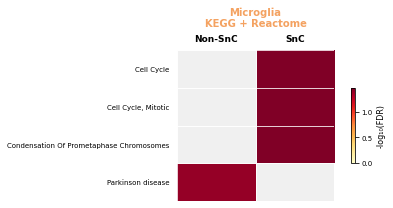


TIER: InSenePy
  No significant pathways in KEGG/Reactome

TIER: NotSenePy
  Microglia: 8 pathways (4 UP, 4 DOWN)
  ✓ Saved: psychad_aging_heatmap_NotSenePy_Microglia_KEGG_Reactome.pdf


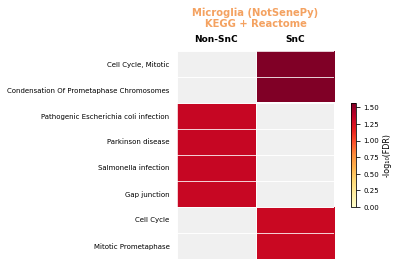


KEGG + REACTOME HEATMAPS COMPLETE


In [9]:
# %% Publication Heatmaps - KEGG + Reactome
# ============================================================
# Focus on curated pathway databases
# ============================================================

print("=" * 60)
print("CREATING HEATMAPS: KEGG + REACTOME")
print("=" * 60)

import textwrap

# ------------------------------------------------------------
# Define helper functions
# ------------------------------------------------------------
def wrap_label(text, width=40):
    """Wrap text to specified width."""
    return '\n'.join(textwrap.wrap(text, width=width))

def clean_term_kegg_reactome(term):
    """Clean KEGG and Reactome pathway names."""
    term = term.replace('KEGG_', '').replace('Reactome_', '')
    term = term.replace(' - Homo sapiens', '').replace('_Homo sapiens', '')
    term = term.replace('_', ' ')
    if ' R-HSA-' in term:
        term = term.split(' R-HSA-')[0]
    return term.strip()

# ------------------------------------------------------------
# Prepare data - combine KEGG and Reactome
# ------------------------------------------------------------
core_databases = ['KEGG_2021_Human', 'Reactome_2022']
top_n = 20

# Process each tier
for tier_name, consolidated_df in [('AllDEGs', all_degs_consolidated),
                                    ('InSenePy', in_senespy_consolidated),
                                    ('NotSenePy', not_senespy_consolidated)]:
    
    if consolidated_df is None or len(consolidated_df) == 0:
        print(f"\n{tier_name}: No data, skipping...")
        continue
    
    print(f"\n{'='*60}")
    print(f"TIER: {tier_name}")
    print(f"{'='*60}")
    
    # Filter by core databases and significance
    sig_df = consolidated_df[
        (consolidated_df['database'].isin(core_databases)) &
        (consolidated_df['Adjusted P-value'] < FDR_THRESHOLD)
    ].copy()
    
    if len(sig_df) == 0:
        print(f"  No significant pathways in KEGG/Reactome")
        continue
    
    # Clean pathway names
    sig_df['Term_clean'] = sig_df['Term'].apply(clean_term_kegg_reactome)
    sig_df['neg_log10_fdr'] = -np.log10(sig_df['Adjusted P-value'].clip(lower=1e-50))
    
    # Get top pathways per cell type
    ct_data_tier = {}
    for ct in CELL_TYPES:
        ct_df = sig_df[sig_df['cell_type'] == ct].copy()
        ct_top = ct_df.nsmallest(top_n, 'Adjusted P-value')
        ct_data_tier[ct] = ct_top
        n_up = len(ct_top[ct_top['direction'] == 'UP'])
        n_down = len(ct_top[ct_top['direction'] == 'DOWN'])
        print(f"  {ct}: {len(ct_top)} pathways ({n_up} UP, {n_down} DOWN)")
    
    vmax_tier = sig_df['neg_log10_fdr'].quantile(0.95) if len(sig_df) > 0 else 5
    
    # ------------------------------------------------------------
    # Create heatmap for each cell type
    # ------------------------------------------------------------
    for ct in CELL_TYPES:
        ct_df = ct_data_tier[ct]
        
        if len(ct_df) == 0:
            print(f"\n  {ct}: No significant pathways, skipping...")
            continue
        
        # Order by significance
        pathway_order = ct_df.groupby('Term_clean')['Adjusted P-value'].min().sort_values().index.tolist()
        n_pathways = len(pathway_order)
        
        # Build heatmap matrix
        heatmap_data = pd.DataFrame(index=pathway_order, columns=['Non-SnC', 'SnC'], dtype=float)
        
        for _, row in ct_df.iterrows():
            pathway = row['Term_clean']
            direction = row['direction']
            value = row['neg_log10_fdr']
            
            if direction == 'DOWN':
                heatmap_data.loc[pathway, 'Non-SnC'] = value
            else:
                heatmap_data.loc[pathway, 'SnC'] = value
        
        data_array = heatmap_data.values.astype(float)
        
        # Wrapped labels
        wrapped_labels = [wrap_label(p, width=40) for p in pathway_order]
        
        # Figure size
        fig_height = max(3, n_pathways * 0.35 + 1)
        fig_width = 5.5
        
        # Create figure
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
        
        # Plot heatmap
        im = ax.imshow(data_array, cmap=COLORS['cmap'], aspect='auto',
                       vmin=0, vmax=vmax_tier)
        
        # White borders
        for i in range(n_pathways + 1):
            ax.axhline(i - 0.5, color='white', linewidth=0.8)
        for j in range(3):
            ax.axvline(j - 0.5, color='white', linewidth=0.8)
        
        # Gray fill for NaN
        for i in range(n_pathways):
            for j in range(2):
                if np.isnan(data_array[i, j]):
                    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                                fill=True, facecolor='#f0f0f0',
                                                edgecolor='white', linewidth=0.8))
        
        # X-axis
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Non-SnC', 'SnC'], fontsize=9, fontweight='bold')
        ax.xaxis.set_ticks_position('top')
        ax.xaxis.set_label_position('top')
        
        # Y-axis
        ax.set_yticks(range(n_pathways))
        ax.set_yticklabels(wrapped_labels, fontsize=7, va='center')
        
        # Limits
        ax.set_xlim(-0.5, 1.5)
        ax.set_ylim(n_pathways - 0.5, -0.5)
        
        # Remove spines
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.tick_params(left=False, top=False)
        
        # Title
        title_suffix = '' if tier_name == 'AllDEGs' else f' ({tier_name})'
        ax.set_title(f'{ct}{title_suffix}\nKEGG + Reactome', fontsize=10, fontweight='bold',
                     color=COLORS.get(ct, 'black'), pad=8)
        
        # Colorbar
        cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.08, aspect=20)
        cbar.set_label('-log₁₀(FDR)', fontsize=8)
        cbar.ax.tick_params(labelsize=7)
        
        plt.tight_layout()
        
        # Save
        save_path = FIGURES_DIR / f'{DATASET}_heatmap_{tier_name}_{ct}_KEGG_Reactome'
        fig.savefig(save_path.with_suffix('.pdf'), dpi=300, bbox_inches='tight', facecolor='white')
        fig.savefig(save_path.with_suffix('.svg'), bbox_inches='tight', facecolor='white')
        print(f"  ✓ Saved: {save_path.with_suffix('.pdf').name}")
        
        plt.show()

print("\n" + "=" * 60)
print("KEGG + REACTOME HEATMAPS COMPLETE")
print("=" * 60)

In [10]:
# %% Summary Tables - KEGG + Reactome
# ============================================================
# Comprehensive tables with genes for all tiers
# ============================================================

print("=" * 60)
print("CREATING SUMMARY TABLES: KEGG + REACTOME")
print("=" * 60)

core_databases = ['KEGG_2021_Human', 'Reactome_2022']

def clean_term_kegg_reactome(term):
    """Clean KEGG and Reactome pathway names."""
    term = term.replace('KEGG_', '').replace('Reactome_', '')
    term = term.replace(' - Homo sapiens', '').replace('_Homo sapiens', '')
    term = term.replace('_', ' ')
    if ' R-HSA-' in term:
        term = term.split(' R-HSA-')[0]
    return term.strip()

def create_pathway_table_kegg_reactome(consolidated_df, tier_name):
    """Create comprehensive pathway table with genes for KEGG + Reactome."""
    
    if consolidated_df is None or len(consolidated_df) == 0:
        print(f"  {tier_name}: No data")
        return None
    
    # Filter by databases and significance
    df = consolidated_df[
        (consolidated_df['database'].isin(core_databases)) &
        (consolidated_df['Adjusted P-value'] < FDR_THRESHOLD)
    ].copy()
    
    if len(df) == 0:
        print(f"  {tier_name}: No significant pathways")
        return None
    
    # Clean pathway names
    df['Pathway'] = df['Term'].apply(clean_term_kegg_reactome)
    
    # Map direction to biological meaning
    df['Enriched_In'] = df['direction'].map({'UP': 'SnC', 'DOWN': 'Non-SnC'})
    
    # Select columns
    table = df[[
        'Pathway',
        'database',
        'cell_type',
        'Enriched_In',
        'Adjusted P-value',
        'Gene_Count',
        'Overlapping Genes'
    ]].copy()
    
    table.columns = [
        'Pathway',
        'Database',
        'Cell_Type',
        'Enriched_In',
        'FDR',
        'Gene_Count',
        'Genes'
    ]
    
    # Sort by cell type, then FDR
    table = table.sort_values(['Cell_Type', 'FDR']).reset_index(drop=True)
    
    print(f"  {tier_name}: {len(table)} pathways")
    
    return table

# ------------------------------------------------------------
# Create tables for each tier
# ------------------------------------------------------------

print("\nCreating tables...")

table_all_degs = create_pathway_table_kegg_reactome(all_degs_consolidated, 'All_DEGs')
table_in_senespy = create_pathway_table_kegg_reactome(in_senespy_consolidated, 'In_SenePy')
table_not_senespy = create_pathway_table_kegg_reactome(not_senespy_consolidated, 'Not_in_SenePy')

# ------------------------------------------------------------
# Save tables
# ------------------------------------------------------------
print("\n" + "-" * 60)
print("SAVING TABLES")
print("-" * 60)

if table_all_degs is not None:
    path = RESULTS_DIR / f'{DATASET}_pathway_table_AllDEGs_KEGG_Reactome.csv'
    table_all_degs.to_csv(path, index=False)
    print(f"✓ {path.name}")

if table_in_senespy is not None:
    path = RESULTS_DIR / f'{DATASET}_pathway_table_InSenePy_KEGG_Reactome.csv'
    table_in_senespy.to_csv(path, index=False)
    print(f"✓ {path.name}")

if table_not_senespy is not None:
    path = RESULTS_DIR / f'{DATASET}_pathway_table_NotSenePy_KEGG_Reactome.csv'
    table_not_senespy.to_csv(path, index=False)
    print(f"✓ {path.name}")

# ------------------------------------------------------------
# Display summaries
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("TABLE SUMMARIES")
print("=" * 60)

for tier_name, table in [('All DEGs', table_all_degs),
                          ('In-SenePy', table_in_senespy),
                          ('Not-in-SenePy', table_not_senespy)]:
    if table is None:
        continue
    
    print(f"\n{'-'*60}")
    print(f"{tier_name}")
    print(f"{'-'*60}")
    
    # Summary by cell type and direction
    summary = table.groupby(['Cell_Type', 'Enriched_In']).agg({
        'Pathway': 'count',
        'Gene_Count': 'sum'
    }).rename(columns={'Pathway': 'N_Pathways', 'Gene_Count': 'Total_Genes'})
    
    print("\nBy Cell Type & Direction:")
    print(summary.to_string())
    
    # Summary by database
    db_summary = table.groupby(['Database', 'Cell_Type']).size().unstack(fill_value=0)
    print("\nBy Database:")
    print(db_summary.to_string())
    
    # Top 5 pathways
    print(f"\nTop 5 Pathways (lowest FDR):")
    top5 = table.nsmallest(5, 'FDR')[['Pathway', 'Database', 'Cell_Type', 'Enriched_In', 'FDR', 'Gene_Count']]
    print(top5.to_string(index=False))

# ------------------------------------------------------------
# Gene frequency analysis
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("GENE FREQUENCY ANALYSIS")
print("=" * 60)

def analyze_gene_frequency(table, tier_name):
    """Analyze which genes appear most frequently across pathways."""
    
    if table is None or len(table) == 0:
        return None
    
    gene_counts = {}
    gene_pathways = {}
    gene_celltypes = {}
    gene_direction = {}
    
    for _, row in table.iterrows():
        if pd.isna(row['Genes']) or row['Genes'] == '':
            continue
        
        genes = row['Genes'].split(';')
        pathway = row['Pathway']
        ct = row['Cell_Type']
        direction = row['Enriched_In']
        
        for gene in genes:
            gene = gene.strip()
            if gene:
                gene_counts[gene] = gene_counts.get(gene, 0) + 1
                
                if gene not in gene_pathways:
                    gene_pathways[gene] = set()
                gene_pathways[gene].add(pathway)
                
                if gene not in gene_celltypes:
                    gene_celltypes[gene] = set()
                gene_celltypes[gene].add(ct)
                
                if gene not in gene_direction:
                    gene_direction[gene] = set()
                gene_direction[gene].add(direction)
    
    # Create frequency table
    freq_df = pd.DataFrame([
        {
            'Gene': gene,
            'N_Pathways': count,
            'N_CellTypes': len(gene_celltypes[gene]),
            'Cell_Types': ', '.join(sorted(gene_celltypes[gene])),
            'Enriched_In': ', '.join(sorted(gene_direction[gene])),
            'Sample_Pathways': '; '.join(sorted(gene_pathways[gene])[:3])
        }
        for gene, count in gene_counts.items()
    ])
    
    freq_df = freq_df.sort_values('N_Pathways', ascending=False).reset_index(drop=True)
    
    return freq_df

# Analyze each tier
gene_freq_all = analyze_gene_frequency(table_all_degs, 'All DEGs')
gene_freq_senespy = analyze_gene_frequency(table_in_senespy, 'In-SenePy')
gene_freq_not_senespy = analyze_gene_frequency(table_not_senespy, 'Not-in-SenePy')

# Save gene frequency tables
print("\nSaving gene frequency tables...")

if gene_freq_all is not None and len(gene_freq_all) > 0:
    path = RESULTS_DIR / f'{DATASET}_gene_frequency_AllDEGs_KEGG_Reactome.csv'
    gene_freq_all.to_csv(path, index=False)
    print(f"✓ {path.name}")

if gene_freq_senespy is not None and len(gene_freq_senespy) > 0:
    path = RESULTS_DIR / f'{DATASET}_gene_frequency_InSenePy_KEGG_Reactome.csv'
    gene_freq_senespy.to_csv(path, index=False)
    print(f"✓ {path.name}")

if gene_freq_not_senespy is not None and len(gene_freq_not_senespy) > 0:
    path = RESULTS_DIR / f'{DATASET}_gene_frequency_NotSenePy_KEGG_Reactome.csv'
    gene_freq_not_senespy.to_csv(path, index=False)
    print(f"✓ {path.name}")

# Display top hub genes
print("\n" + "=" * 60)
print("TOP HUB GENES (appear in multiple pathways)")
print("=" * 60)

for tier_name, freq_df in [('All DEGs', gene_freq_all),
                            ('In-SenePy', gene_freq_senespy),
                            ('Not-in-SenePy', gene_freq_not_senespy)]:
    if freq_df is None or len(freq_df) == 0:
        print(f"\n{tier_name}: No genes")
        continue
    
    print(f"\n{tier_name} - Top 10 Hub Genes:")
    print(freq_df.head(10)[['Gene', 'N_Pathways', 'N_CellTypes', 'Cell_Types', 'Enriched_In']].to_string(index=False))

print("\n" + "=" * 60)
print("SUMMARY TABLES COMPLETE")
print("=" * 60)

CREATING SUMMARY TABLES: KEGG + REACTOME

Creating tables...
  All_DEGs: 4 pathways
  In_SenePy: No significant pathways
  Not_in_SenePy: 8 pathways

------------------------------------------------------------
SAVING TABLES
------------------------------------------------------------
✓ psychad_aging_pathway_table_AllDEGs_KEGG_Reactome.csv
✓ psychad_aging_pathway_table_NotSenePy_KEGG_Reactome.csv

TABLE SUMMARIES

------------------------------------------------------------
All DEGs
------------------------------------------------------------

By Cell Type & Direction:
                       N_Pathways  Total_Genes
Cell_Type Enriched_In                         
Microglia Non-SnC               1            4
          SnC                   3           17

By Database:
Cell_Type        Microglia
Database                  
KEGG_2021_Human          1
Reactome_2022            3

Top 5 Pathways (lowest FDR):
                                 Pathway        Database Cell_Type Enriched_In      

In [11]:
# %% Sankey Diagram - KEGG + Reactome
# ============================================================
# Visualize gene → pathway → cell type relationships
# ============================================================

print("=" * 60)
print("CREATING SANKEY DIAGRAM")
print("=" * 60)

try:
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
    print("✓ Plotly loaded")
except ImportError:
    PLOTLY_AVAILABLE = False
    print("✗ Plotly not available - install with: pip install plotly")

# Check for kaleido (static image export)
try:
    import kaleido
    KALEIDO_AVAILABLE = True
    print("✓ Kaleido loaded (PDF/SVG export available)")
except ImportError:
    KALEIDO_AVAILABLE = False
    print("✗ Kaleido not available - install with: pip install -U kaleido")

if PLOTLY_AVAILABLE:
    
    # ------------------------------------------------------------
    # Prepare data from All DEGs (KEGG + Reactome)
    # ------------------------------------------------------------
    core_databases = ['KEGG_2021_Human', 'Reactome_2022']
    top_n_pathways = 8
    max_genes_per_pathway = 10
    
    # Filter significant results
    sig_df = all_degs_consolidated[
        (all_degs_consolidated['database'].isin(core_databases)) &
        (all_degs_consolidated['Adjusted P-value'] < FDR_THRESHOLD)
    ].copy()
    
    # Clean pathway names
    sig_df['Pathway'] = sig_df['Term'].apply(clean_term_kegg_reactome)
    
    # Get top pathways per cell type
    top_pathways_df = []
    for ct in CELL_TYPES:
        ct_df = sig_df[sig_df['cell_type'] == ct].nsmallest(top_n_pathways, 'Adjusted P-value')
        top_pathways_df.append(ct_df)
    
    plot_df = pd.concat(top_pathways_df, ignore_index=True)
    
    print(f"\nPathways included: {plot_df['Pathway'].nunique()}")
    print(f"Cell types: {plot_df['cell_type'].unique().tolist()}")
    
    # ------------------------------------------------------------
    # Build Sankey data structures
    # ------------------------------------------------------------
    
    genes_set = set()
    pathways_set = set()
    gene_pathway_links = []
    
    for _, row in plot_df.iterrows():
        pathway = row['Pathway']
        ct = row['cell_type']
        direction = row['direction']
        
        if pd.isna(row['Overlapping Genes']) or row['Overlapping Genes'] == '':
            continue
        
        genes = [g.strip() for g in row['Overlapping Genes'].split(';') if g.strip()]
        genes = genes[:max_genes_per_pathway]
        
        pathways_set.add(pathway)
        
        for gene in genes:
            genes_set.add(gene)
            gene_pathway_links.append({
                'gene': gene,
                'pathway': pathway,
                'cell_type': ct,
                'direction': direction
            })
    
    print(f"Genes included: {len(genes_set)}")
    print(f"Gene-pathway links: {len(gene_pathway_links)}")
    
    # ------------------------------------------------------------
    # Create node indices
    # ------------------------------------------------------------
    
    genes_list = sorted(genes_set)
    pathways_list = sorted(pathways_set)
    celltypes_list = CELL_TYPES
    
    node_labels = genes_list + pathways_list + celltypes_list
    
    gene_idx = {g: i for i, g in enumerate(genes_list)}
    pathway_idx = {p: i + len(genes_list) for i, p in enumerate(pathways_list)}
    celltype_idx = {ct: i + len(genes_list) + len(pathways_list) for i, ct in enumerate(celltypes_list)}
    
    # ------------------------------------------------------------
    # Build links
    # ------------------------------------------------------------
    
    gene_to_pathway = {}
    for link in gene_pathway_links:
        key = (link['gene'], link['pathway'])
        if key not in gene_to_pathway:
            gene_to_pathway[key] = {'count': 0, 'direction': link['direction']}
        gene_to_pathway[key]['count'] += 1
    
    pathway_to_ct = {}
    for link in gene_pathway_links:
        key = (link['pathway'], link['cell_type'])
        if key not in pathway_to_ct:
            pathway_to_ct[key] = {'count': 0, 'direction': link['direction']}
        pathway_to_ct[key]['count'] += 1
    
    sources = []
    targets = []
    values = []
    link_colors = []
    
    color_up = 'rgba(231, 111, 81, 0.5)'    # Burnt sienna (SnC)
    color_down = 'rgba(42, 157, 143, 0.5)'  # Teal (Non-SnC)
    
    for (gene, pathway), data in gene_to_pathway.items():
        sources.append(gene_idx[gene])
        targets.append(pathway_idx[pathway])
        values.append(data['count'])
        link_colors.append(color_up if data['direction'] == 'UP' else color_down)
    
    for (pathway, ct), data in pathway_to_ct.items():
        sources.append(pathway_idx[pathway])
        targets.append(celltype_idx[ct])
        values.append(data['count'])
        link_colors.append(color_up if data['direction'] == 'UP' else color_down)
    
    # ------------------------------------------------------------
    # Node colors
    # ------------------------------------------------------------
    node_colors = []
    
    for _ in genes_list:
        node_colors.append('rgba(150, 150, 150, 0.8)')
    
    for _ in pathways_list:
        node_colors.append('rgba(100, 100, 100, 0.8)')
    
    for ct in celltypes_list:
        if ct == 'Microglia':
            node_colors.append('rgba(244, 162, 97, 0.9)')
        elif ct == 'Astrocyte':
            node_colors.append('rgba(38, 70, 83, 0.9)')
        elif ct == 'OPC':
            node_colors.append('rgba(138, 177, 125, 0.9)')
        else:
            node_colors.append('rgba(150, 150, 150, 0.8)')
    
    # ------------------------------------------------------------
    # Create Sankey figure
    # ------------------------------------------------------------
    fig = go.Figure(data=[go.Sankey(
        arrangement='snap',
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color='white', width=0.5),
            label=node_labels,
            color=node_colors
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=link_colors
        )
    )])
    
    fig.update_layout(
        title=dict(
            text=f'{DISPLAY_NAME}: Gene → Pathway → Cell Type<br><sub>KEGG + Reactome | Top {top_n_pathways} pathways per cell type</sub>',
            font=dict(size=14),
            x=0.5,
            xanchor='center'
        ),
        font=dict(size=10, family='Arial'),
        height=800,
        width=1200,
        paper_bgcolor='white',
        plot_bgcolor='white',
        margin=dict(t=80, l=20, r=20, b=40)
    )
    
    # Legend - TOP LEFT
    fig.add_annotation(
        x=0.01, y=0.99,
        xref='paper', yref='paper',
        xanchor='left', yanchor='top',
        text='<b>Link color:</b><br>■ Teal = Non-SnC enriched<br>■ Orange = SnC enriched',
        showarrow=False,
        font=dict(size=10),
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='gray',
        borderwidth=1,
        borderpad=5
    )
    
    # ------------------------------------------------------------
    # Save outputs
    # ------------------------------------------------------------
    
    # HTML (interactive)
    sankey_html = FIGURES_DIR / f'{DATASET}_sankey_AllDEGs_KEGG_Reactome.html'
    fig.write_html(sankey_html)
    print(f"\n✓ Saved: {sankey_html.name}")
    
    # PDF and SVG (static)
    if KALEIDO_AVAILABLE:
        sankey_pdf = FIGURES_DIR / f'{DATASET}_sankey_AllDEGs_KEGG_Reactome.pdf'
        sankey_svg = FIGURES_DIR / f'{DATASET}_sankey_AllDEGs_KEGG_Reactome.svg'
        sankey_png = FIGURES_DIR / f'{DATASET}_sankey_AllDEGs_KEGG_Reactome.png'
        
        fig.write_image(sankey_pdf, scale=2)
        print(f"✓ Saved: {sankey_pdf.name}")
        
        fig.write_image(sankey_svg)
        print(f"✓ Saved: {sankey_svg.name}")
        
        fig.write_image(sankey_png, scale=2)
        print(f"✓ Saved: {sankey_png.name}")
    else:
        print("\n⚠ Install kaleido for PDF/SVG export: pip install -U kaleido")
    
    fig.show()
    
    print("\n✓ Sankey diagram complete")

else:
    print("\nSkipping Sankey - Plotly not available")

CREATING SANKEY DIAGRAM
✓ Plotly loaded
✓ Kaleido loaded (PDF/SVG export available)

Pathways included: 4
Cell types: ['Microglia']
Genes included: 12
Gene-pathway links: 21

✓ Saved: psychad_aging_sankey_AllDEGs_KEGG_Reactome.html
✓ Saved: psychad_aging_sankey_AllDEGs_KEGG_Reactome.pdf
✓ Saved: psychad_aging_sankey_AllDEGs_KEGG_Reactome.svg
✓ Saved: psychad_aging_sankey_AllDEGs_KEGG_Reactome.png



✓ Sankey diagram complete


In [12]:
# %% Final Summary and Export
# ============================================================
# Module 06a Summary
# ============================================================

print("=" * 60)
print("MODULE 06a: FINAL SUMMARY")
print("=" * 60)

# ------------------------------------------------------------
# Files generated
# ------------------------------------------------------------
print("\n" + "-" * 60)
print("FILES GENERATED")
print("-" * 60)

# Count files
results_files = list(RESULTS_DIR.glob(f'{DATASET}*'))
figures_files = list(FIGURES_DIR.glob(f'{DATASET}*'))

print(f"\nResults directory: {RESULTS_DIR}")
print(f"  Total files: {len(results_files)}")
for f in sorted(results_files):
    print(f"    • {f.name}")

print(f"\nFigures directory: {FIGURES_DIR}")
print(f"  Total files: {len(figures_files)}")
for f in sorted(figures_files):
    print(f"    • {f.name}")

# ------------------------------------------------------------
# Analysis summary
# ------------------------------------------------------------
print("\n" + "-" * 60)
print("ANALYSIS SUMMARY")
print("-" * 60)

print(f"\nDataset: {DISPLAY_NAME} ({DATASET})")
print(f"Comparison: {COMPARISON_DISPLAY}")
print(f"Cell types: {', '.join(CELL_TYPES)}")

print(f"\n{'Tier':<20} {'Total Sig':<12} {'KEGG+Reactome':<15}")
print("-" * 47)

for tier_name, consolidated_df in [('All DEGs', all_degs_consolidated),
                                    ('In-SenePy', in_senespy_consolidated),
                                    ('Not-in-SenePy', not_senespy_consolidated)]:
    if consolidated_df is None:
        continue
    
    total_sig = len(consolidated_df[consolidated_df['Adjusted P-value'] < FDR_THRESHOLD])
    kegg_reactome = len(consolidated_df[
        (consolidated_df['Adjusted P-value'] < FDR_THRESHOLD) &
        (consolidated_df['database'].isin(['KEGG_2021_Human', 'Reactome_2022']))
    ])
    
    print(f"{tier_name:<20} {total_sig:<12} {kegg_reactome:<15}")

# ------------------------------------------------------------
# Key findings
# ------------------------------------------------------------
print("\n" + "-" * 60)
print("KEY FINDINGS")
print("-" * 60)

print("""
1. DIRECTION BIAS:
   - Most pathways enriched in Non-SnC (downregulated in senescent cells)
   - Suggests loss of function in senescent glia

2. CELL TYPE PATTERNS:
   - Astrocyte: Strongest signal (translation, synaptic pathways)
   - OPC: Moderate signal (synaptic, neuronal pathways)
   - Microglia: Fewer pathways, some SnC-enriched

3. IN-SENESPY VALIDATION:
   - Translation/ribosome pathways down in Astrocytes
   - Confirms SenePy captures canonical senescence biology

4. NOT-IN-SENESPY DISCOVERY:
   - Synaptic genes (GRIN2A/B, GABRA1) are novel findings
   - Cell-type-specific biology beyond canonical senescence

5. HUB GENES:
   - Ribosomal proteins (RPS/RPL) in translation shutdown
   - Glutamate receptors (GRIN) in synaptic dysfunction
""")

# ------------------------------------------------------------
# Next steps
# ------------------------------------------------------------
print("-" * 60)
print("NEXT STEPS")
print("-" * 60)

print("""
1. Module 06b: Run SCPA analysis (R)
   - Compare pathway activity using expression data
   - Same KEGG + Reactome databases for comparison

2. Integrate findings:
   - Compare ORA vs SCPA results
   - Identify convergent pathways

3. Manuscript figures:
   - Figure 2D: Heatmap (All DEGs, KEGG + Reactome)
   - Supplementary: In-SenePy / Not-in-SenePy heatmaps
   - Supplementary: Sankey diagram
""")

print("\n" + "=" * 60)
print("MODULE 06a COMPLETE")
print("=" * 60)

MODULE 06a: FINAL SUMMARY

------------------------------------------------------------
FILES GENERATED
------------------------------------------------------------

Results directory: /fs/scratch/PAS2598/senescence_analysis/results/06_pathway_enrichment/psychad_aging
  Total files: 24
    • psychad_aging_All_DEGs_enrichment.csv
    • psychad_aging_In_SenePy_enrichment.csv
    • psychad_aging_Not_in_SenePy_enrichment.csv
    • psychad_aging_all_enrichment_results.csv
    • psychad_aging_deg_stratification_summary.csv
    • psychad_aging_gene_frequency_AllDEGs_KEGG_Reactome.csv
    • psychad_aging_gene_frequency_InSenePy_KEGG_Reactome.csv
    • psychad_aging_gene_frequency_NotSenePy_KEGG_Reactome.csv
    • psychad_aging_heatmap_AllDEGs_companion_table.csv
    • psychad_aging_heatmap_companion_table.csv
    • psychad_aging_pathway_table_AllDEGs_KEGG_Reactome.csv
    • psychad_aging_pathway_table_InSenePy_KEGG_Reactome.csv
    • psychad_aging_pathway_table_NotSenePy_KEGG_Reactome.csv
    